In [5]:
import os

os.makedirs("../models", exist_ok=True)

In [6]:
import pandas as pd

df = pd.read_csv("../data/WELFake_Dataset.csv")

# Clean
df = df.dropna(subset=["text", "label"]).copy()
df["title"] = df["title"].fillna("")

# Combine text + title
df["combined"] = df["title"] + " " + df["text"]

X = df["combined"]
y = df["label"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
import re
import nltk
import spacy
from sklearn.base import BaseEstimator, TransformerMixin

from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

class TextPreprocessor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return [self._clean(text) for text in X]
    
    def _clean(self, text):
        if not isinstance(text, str):
            return ""
        
        text = text.lower()
        text = re.sub(r'http\S+|www\.\S+', ' ', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'[^a-z\s]', ' ', text)
        
        doc = nlp(text)
        
        tokens = [
            token.lemma_ for token in doc
            if token.text not in STOPWORDS
            and len(token.text) > 2
            and not token.is_space
        ]
        
        return " ".join(tokens)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb

# Import your preprocessor from previous notebook
# (if needed, copy the class into this notebook)

pipeline = Pipeline([
    ("preprocessor", TextPreprocessor()),
    
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("model", xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42
    ))
])

In [11]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [12]:
from sklearn.metrics import classification_report, f1_score

y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      7006
           1       0.96      0.98      0.97      7413

    accuracy                           0.97     14419
   macro avg       0.97      0.97      0.97     14419
weighted avg       0.97      0.97      0.97     14419

Macro F1: 0.9702738492923331


In [13]:
import pickle

with open("../models/tfidf_xgboost_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

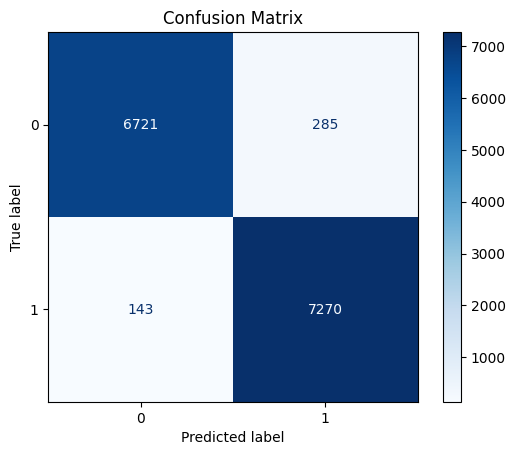

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [16]:
train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test.reset_index(drop=True)
})

train_df.to_csv("../data/train_distilbert.csv", index=False)
test_df.to_csv("../data/test_distilbert.csv", index=False)